In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [37]:
df_index=pd.read_csv("height-weight.csv")

In [38]:
df_index.head()

,Weight,height,age
0,42,160,26
1,69,195,38
2,63,151,40
3,69,187,39
4,81,182,39


In [39]:
df_index.head()

,Weight,height,age
0,42,160,26
1,69,195,38
2,63,151,40
3,69,187,39
4,81,182,39


In [40]:
##check null values
df_index.isnull().sum()

Weight    0
height    0
age       0
dtype: int64

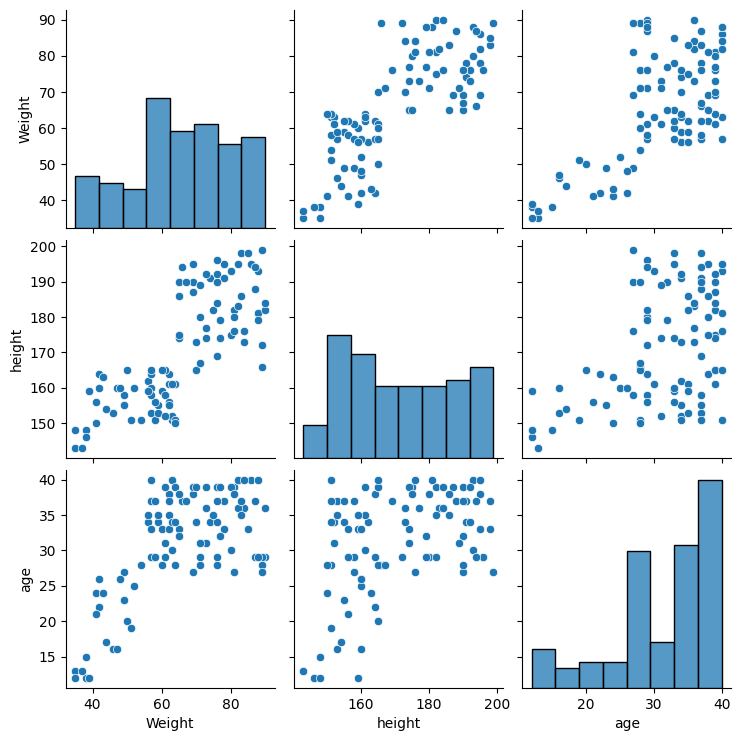

In [41]:
## Lets do some viualization
import seaborn as sns
sns.pairplot(df_index)

In [42]:
df_index.corr()

,Weight,height,age
Weight,1.000000,0.770491,0.654360
height,0.770491,1.000000,0.486387
age,0.654360,0.486387,1.000000


Text(0, 0.5, 'age')

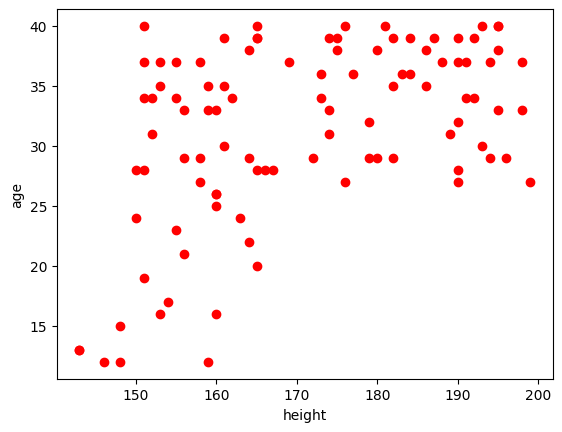

In [43]:
## Visualiza the datapoints more closely
plt.scatter(df_index['height'],df_index['age'],color='r')
plt.xlabel("height")
plt.ylabel("age")

Text(0, 0.5, 'age')

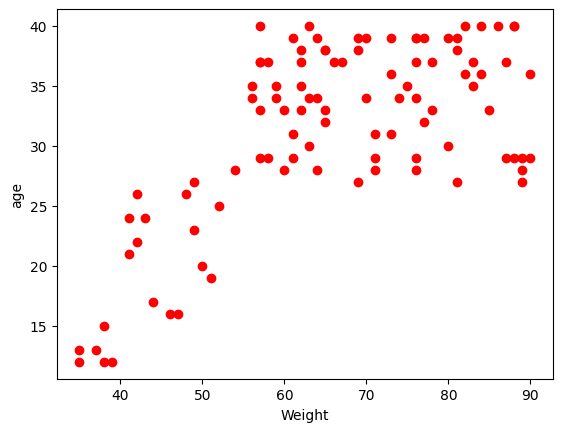

In [44]:
## Visualiza the datapoints more closely
plt.scatter(df_index['Weight'],df_index['age'],color='r')
plt.xlabel("Weight")
plt.ylabel("age")

In [45]:
##independent and dependent features
X=df_index.iloc[:,:-1]
y=df_index.iloc[:,-1]

In [46]:
X.head()

,Weight,height
0,42,160
1,69,195
2,63,151
3,69,187
4,81,182


In [47]:
y

0     26
1     38
2     40
3     39
4     39
      ..
94    39
95    36
96    28
97    37
98    24
Name: age, Length: 99, dtype: int64

In [48]:
# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [49]:
import seaborn as sns


In [50]:
X_train

,Weight,height
33,81,176
9,59,155
81,85,198
11,50,165
65,61,165
...,...,...
60,87,188
71,59,153
14,65,174
92,71,189


In [51]:
y_train

33    27
9     34
81    33
11    20
65    39
      ..
60    37
71    35
14    33
92    31
51    35
Name: age, Length: 74, dtype: int64

In [52]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [53]:
regression.fit(X_train,y_train)

LinearRegression()

In [54]:
## prediction
y_pred=regression.predict(X_test)

In [55]:
X_test

,Weight,height
62,83,186
40,62,164
95,73,177
18,76,192
97,67,190
84,77,174
64,76,190
42,62,161
10,42,164
0,42,160


In [56]:
y_pred

array([36.56901226, 30.48450982, 33.57474655, 33.6657671 , 30.57057993,
       35.20561628, 33.79702875, 30.6814023 , 23.31462354, 23.57714684,
       34.18586325, 23.48117583, 36.40741042, 22.90039931, 37.7807073 ,
       36.11454693, 22.18341068, 40.03259466, 38.82089961, 36.24580858,
       29.08582321, 24.68792043, 35.17527609, 22.9307395 , 26.21786869])

In [57]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

32.33829849620906
4.51594542782053
5.686677280821294


In [58]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)
#display adjusted R-squared
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.5615740442487925
0.521717139180501


## Assumptions

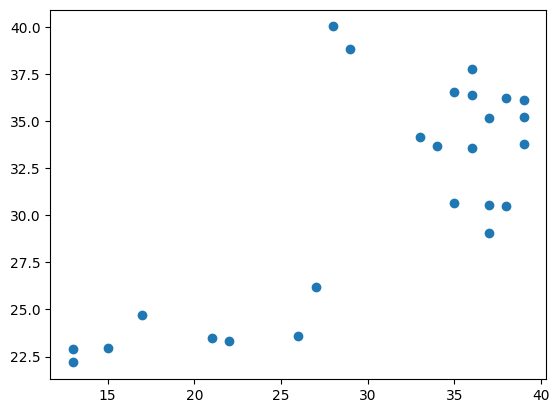

In [59]:
plt.scatter(y_test,y_pred)

In [60]:
residuals=y_test-y_pred
print(residuals)

62    -1.569012
40     7.515490
95     2.425253
18     0.334233
97     6.429420
84     3.794384
64     5.202971
42     4.318598
10    -1.314624
0      2.422853
31    -1.185863
76    -2.481176
47    -0.407410
26    -9.900399
44    -1.780707
4      2.885453
22    -9.183411
12   -12.032595
88    -9.820900
73     1.754191
49     7.914177
70    -7.687920
68     1.824724
15    -7.930739
39     0.782131
Name: age, dtype: float64


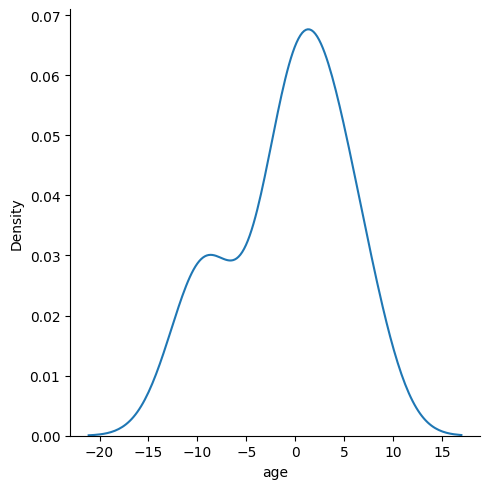

In [61]:
## Plot this residuals
sns.displot(residuals,kind='kde')

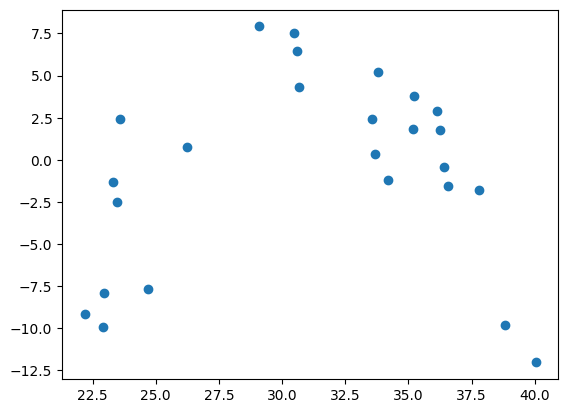

In [62]:
## scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)

In [63]:
## OLS Linear Regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [64]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                    age   R-squared (uncentered):                   0.966
Model:                            OLS   Adj. R-squared (uncentered):              0.966
Method:                 Least Squares   F-statistic:                              1038.
Date:                Tue, 03 Feb 2026   Prob (F-statistic):                    8.19e-54
Time:                        15:08:43   Log-Likelihood:                         -236.60
No. Observations:                  74   AIC:                                      477.2
Df Residuals:                      72   BIC:                                      481.8
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Weight         0.2781      0.071      3.899      0.000       0.136       0.420
height         0.0757      0.028      2.697      0.009       0.020       0.132
==============================================================================
Omnibus:                        3.974   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.137   Jarque-Bera (JB):                2.363
Skew:                          -0.211   Prob(JB):                        0.307
Kurtosis:                       2.233   Cond. No.                         20.3
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [65]:
print(regression.coef_)

[ 0.35849431 -0.06563083]


In [66]:
regression.intercept_

19.021317761437658

In [67]:
weight_p = float(input("Enter weight: "))
height_p = float(input("Enter height: "))

prediction = model.predict([[weight_p, height_p]])
print("Predicted age is:", prediction[0])


Predicted age is: 16.60314031633337
